In [174]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

In [175]:
df= pd.read_csv('./Full Uganda Data.csv')

In [176]:
# strip whitespace, replace spaces/slashes with underscores
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(r'\s+', '_', regex=True)
      .str.replace(r'[\/\(\)\-]', '', regex=True)
)

In [177]:

def clean_text(s):
    if pd.isnull(s):
        return s
    s = s.strip()                        # Remove leading/trailing whitespace
    s = re.sub(r'\s+', ' ', s)          # Replace multiple spaces with single
    s = s.lower()                       # Convert to lowercase (optional)
    s = s.replace('_', ' ')             # Replace underscores with space
    s = s.title()                       # Convert to Title Case
    return s

# Apply cleaning to each text column
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
for col in cat_cols:
    df[col] = df[col].astype(str).apply(clean_text)

In [178]:
df = df[df['tags'] == 'Game']

In [179]:
df.head()

,date,session_title,player_name,split_name,tags,split_start_time,split_end_time,duration,distance_km,sprint_distance_m,...,accelerations_zone_count:_0__1_mss,accelerations_zone_count:_1__2_mss,accelerations_zone_count:_2__3_mss,accelerations_zone_count:_3__4_mss,accelerations_zone_count:_>_4_mss,deceleration_zone_count:_0__1_mss,deceleration_zone_count:_1__2_mss,deceleration_zone_count:_2__3_mss,deceleration_zone_count:_3__4_mss,deceleration_zone_count:_>_4_mss
0,13/09/2024,Md1-Kcca Fc-Ura Fc-Home-League-Win,Haruna Lukwago-Kcca-Rb,All,Game,45548.83479,45548.88245,2949,5.9520,867.171,...,0,101,88,38,25,0,106,83,34,27
1,16/09/2024,Md1-Sc Villa-Mbarara City Fc-Home-League-Win,Aslam Ssemakula - Villa - Mf,All,Game,45551.63287,45551.74712,6389,11.7800,1237.216,...,0,287,148,37,14,0,231,108,48,28
2,16/09/2024,Md1-Sc Villa-Mbarara City Fc-Home-League-Win,Hakim Kiwanuka - Villa - Rw,All,Game,45551.63278,45551.72971,4892,8.7900,1484.303,...,0,173,89,26,24,0,181,54,28,25
3,16/09/2024,Md1-Sc Villa-Mbarara City Fc-Home-League-Win,Ronald Ssekiganda - Villa - Mf,All,Game,45551.63628,45551.74866,6272,13.6827,1703.742,...,0,256,200,75,28,0,233,142,79,60
4,16/09/2024,Md1-Sc Villa-Mbarara City Fc-Home-League-Win,Francis Onekalit - Villa - Fwd,All,Game,45551.63573,45551.71420,3298,5.6856,741.399,...,0,107,84,44,18,0,112,65,28,29


In [180]:
df['duration'] = df['duration'] / 60 #convert duration to minutes for easy comparison

In [181]:
#select only the first and second halves ; ensure proper naming of splits
df = df[((df['split_name'] == '1St.Half') | (df['split_name'] == '2Nd.Half'))]
df['split_name'] = df['split_name'].str.replace('1St.Half', '1st Half')
df['split_name'] = df['split_name'].str.replace('2Nd.Half', '2nd Half')

In [182]:
df[['p_name', 'player_club_', 'player_position']] = df['player_name'].str.split('-', n=2, expand=True)
df = df.drop('player_name', axis=1)

In [183]:
df['player_position'] = df['player_position'].str.strip()
df = df[df['player_position'] != 'Gk']

In [184]:
df[['match_day', 'club_for', 'club_against', 'location', 'league', 'result']] = df['session_title'].str.split('-', n=5, expand=True)

In [185]:
# Apply cleaning to each text column again to catch any new text data
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
for col in cat_cols:
    df[col] = df[col].astype(str).apply(clean_text)
    df[col] = df[col].astype('category')

In [186]:
df = df[df['match_day'].str.startswith('Md')]

In [187]:
# list of standard UPL club names
standard_clubs = [
    "KCCA FC", "BUL FC", "URA FC", "Vipers SC", "Express FC", "SC Villa",
    "Maroons FC", "Wakiso Giants FC", "Soltilo Bright Stars FC", "Police FC",
    "UPDF FC", "NEC FC", "Mbarara City FC", "Kitara FC",'Lugazi FC','Mbale Heroes FC'
]
def normalize_name(name):
    # Remove spaces, punctuation, and 'fc', 'sc', etc.
    name = name.lower()
    name = re.sub(r'[^a-z]', '', name)  # keep only letters
    name = name.replace('fc', '').replace('sc', '')
    return name

def best_match(name, club_list, min_score=0.6):
    name_clean = name.strip().lower().replace('.', '')
    norm_name = normalize_name(name_clean)
    # 1. Normalized exact match
    for club in club_list:
        if norm_name == normalize_name(club):
            return club
    # 2. Normalized substring match
    for club in club_list:
        club_norm = normalize_name(club)
        if norm_name in club_norm or club_norm in norm_name:
            return club
    # 3. Token overlap (as before)
    name_tokens = set(name_clean.split())
    best = None
    best_score = 0
    for club in club_list:
        club_tokens = set(club.strip().lower().replace('.', '').split())
        score = len(name_tokens & club_tokens) / max(len(club_tokens), 1)
        if score > best_score:
            best = club
            best_score = score
    return best if best_score >= min_score else name

# Apply to all columns with club names 
for col in ['club_for', 'club_against', 'player_club_']:
    if col in df.columns:
        df[col] = df[col].astype(str).apply(lambda x: best_match(x, standard_clubs))


In [188]:
for col in ['club_for', 'club_against', 'player_club_']:
    if col in df.columns:
        df[col] = df[col].replace('Solitilo Bright Stars', 'Soltilo Bright Stars FC')
        df[col] = df[col].replace('Soltito Bright Stars', 'Soltilo Bright Stars FC')
        df[col] = df[col].replace('Solitilo', 'Soltilo Bright Stars FC')
        df[col] = df[col].replace('Soliyilo', 'Soltilo Bright Stars FC')
        df[col] = df[col].replace('Lugzi', 'Lugazi FC')

In [189]:
# Drop rows where any of the specified columns are not in standard_clubs
cols_to_check = ['club_for', 'club_against', 'player_club_']
mask = df[cols_to_check].apply(lambda x: all(val in standard_clubs for val in x), axis=1)
df = df[mask]

In [190]:
half2_df = df[df['split_name'] == '2Nd Half']
half2_df = half2_df.drop('split_name', axis=1)

half1_df = df[df['split_name'] == '1St Half']
half1_df = half1_df.drop('split_name', axis=1)
merge_keys = ['p_name', 'club_for', 'club_against', 'player_club_','match_day','player_position','result','location']

half1_df_rn = half1_df.rename(columns=lambda x: x + '_H1' if x not in merge_keys else x)
half2_df_rn = half2_df.rename(columns=lambda x: x + '_H2' if x not in merge_keys else x)

df_merged = pd.merge(half1_df_rn, half2_df_rn, on=merge_keys, how='outer')


df_combined = df_merged[merge_keys].copy()

# Numerical Variables of high interest - consider sum
for col in df.select_dtypes(include=['float64', 'int64']).columns:#all numeric columns:
    if col not in ['top_speed_kmh', 'distance_per_min_mmin']:
        h1 = f"{col}_H1"
        h2 = f"{col}_H2"
        # Use .fillna(0) to handle missing halves
        df_combined[col] = df_merged[h1].fillna(0) + df_merged[h2].fillna(0)

# Top Speed - consider max
df_combined['top_speed_kmh'] = df_merged[['top_speed_kmh_H1', 'top_speed_kmh_H2']].max(axis=1)

# distance per minute - recalculate from sum
df_combined['distance_per_min_mmin'] = (df_combined['distance_km'] *1000) / df_combined['duration']

#all other numerical variables - consider sum
# Columns in numeric_cols that are not in num_cols
for col in df.select_dtypes(include=['float64', 'int64']).columns:#all numeric columns:
    if col not in ['club_for', 'match_day','p_name','player_position']:
        h1 = f"{col}_H1"
        h2 = f"{col}_H2"
        # Only sum if both columns exist in df_merged
        if h1 in df_merged.columns and h2 in df_merged.columns:
            df_combined[col] = df_merged[h1].fillna(0) + df_merged[h2].fillna(0)
match_df = df_combined

In [191]:
# Thresholds: adjust based on domain knowledge
DIST_THRESH = 2   # players should cover at least 0.5km in a session to count
DURATION_THRESH = 60  # players should be active for at least 10 minutes in a session    

# Extend your active_session flag:
match_df['active_session'] = (
    (match_df['distance_km']    >= DIST_THRESH)  
    & (match_df['duration']  >= DURATION_THRESH)   
)

match_df = match_df[match_df['active_session'] == True]  # Filter main match_df for active sessions
match_df = match_df.drop('active_session', axis=1)  # Drop the active_session column after filtering

<Axes: ylabel='duration'>

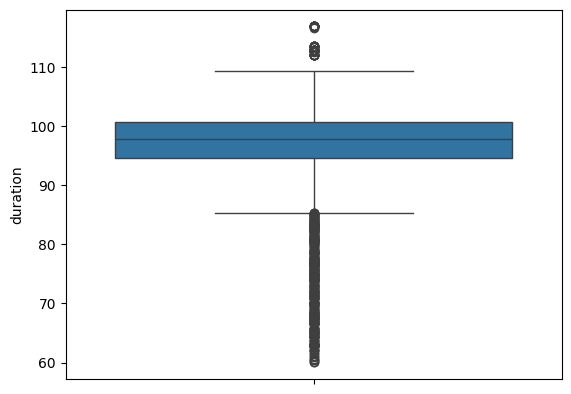

In [192]:
sns.boxplot(data=match_df, y='duration')

In [ ]:
q1 = match_df['distance_km'].quantile(0.25)
q3 = match_df['distance_km'].quantile(0.75)
iqr = q3 - q1
lower_bound_dist = q1 - 1.5 * iqr
upper_bound_dist = q3 + 1.5 * iqr

q1 = match_df['duration'].quantile(0.25)
q3 = match_df['duration'].quantile(0.75)
iqr = q3 - q1
lower_bound_dur = q1 - 1.5 * iqr
upper_bound_dur = q3 + 1.5 * iqr

#filter out outliers based on the calculated bounds
match_df = match_df[
    (match_df['distance_km'] >= lower_bound_dist) & (match_df['distance_km'] <= upper_bound_dist) &
    (match_df['duration'] >= lower_bound_dur) & (match_df['duration'] <= upper_bound_dur)
]

In [193]:
match_df.shape

(4308, 103)

In [194]:
df['player_position'].unique()

['Rb', 'Mf', 'Rw', 'Fwd', 'Df', ..., 'Cf', 'Cd', 'Mc', 'Lcb', 'Md']
Length: 21
Categories (23, object): ['Am', 'Amc', 'Cb', 'Cd', ..., 'Muslim-Am', 'None', 'Rb', 'Rw']

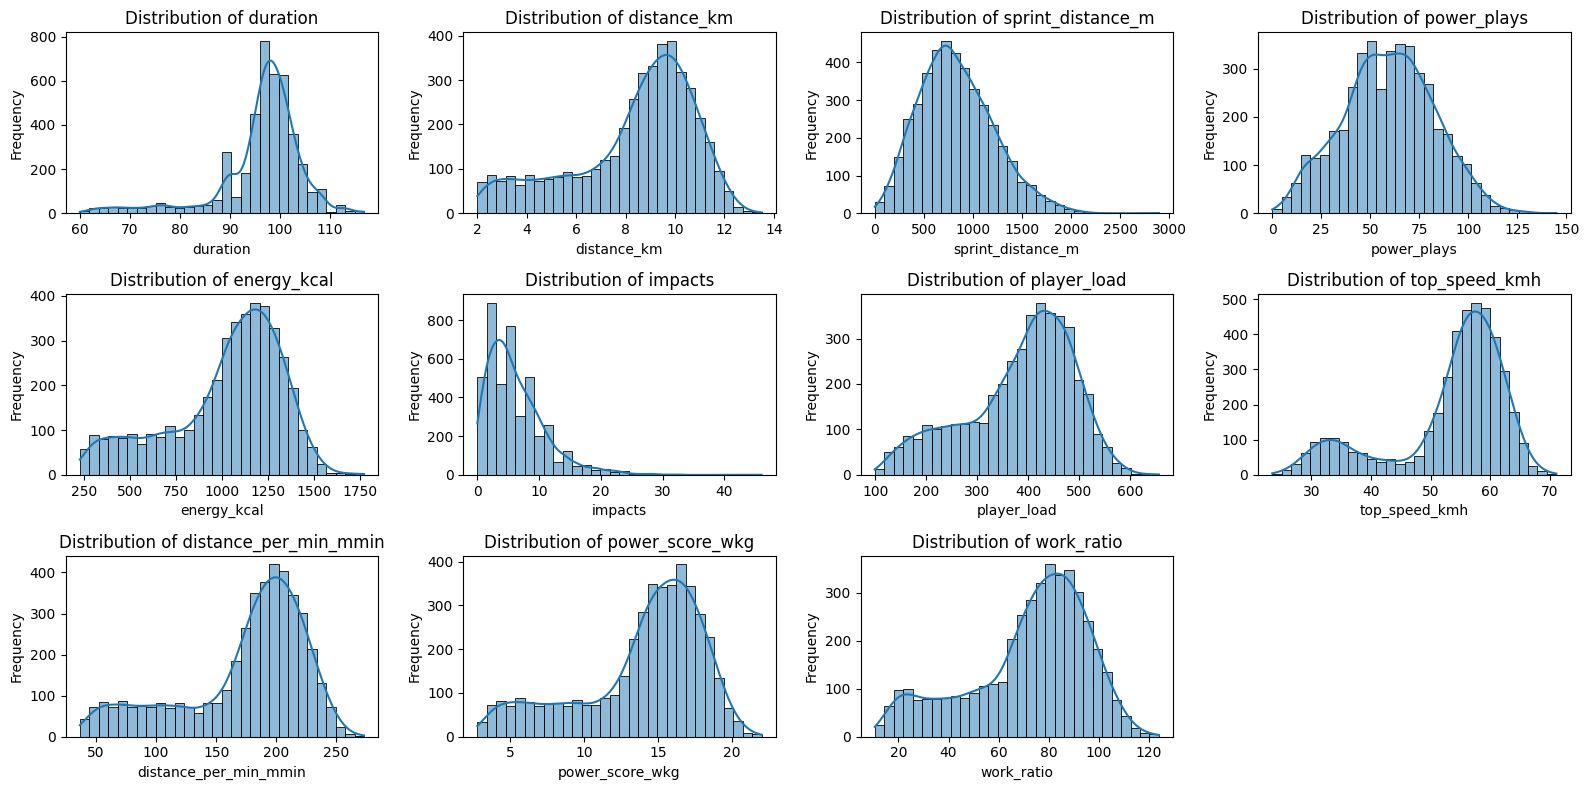

In [195]:
num_cols = ['duration','distance_km','sprint_distance_m','power_plays','energy_kcal','impacts',
                   'player_load','top_speed_kmh','distance_per_min_mmin','power_score_wkg','work_ratio']# numeric columns of high interest
def plot_numerical_distributions(df):
    plt.figure(figsize=(16, 8))
    for i, col in enumerate(num_cols):
        plt.subplot(3, 4, i + 1)
        sns.histplot(df[col], bins=30, kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
    plt.tight_layout()

plot_numerical_distributions(match_df)

In [ ]:
match_df